# 20 - Dynamic resilience - peak hours vs off-peak

The whole resilience story told in notebooks `03`-`06` rests on a single graph that is **averaged over time**: an edge `u - v` exists if *any* trip on *any* service day runs from `u` to `v`, and its weight is the total number of such trips. That graph describes a network that doesn't exist in reality - no rider ever travels on the average of 24 hours. Notebook `19` cut the feed into time windows and rebuilt the graph separately inside each one. This notebook uses those per-window graphs to ask the question the static analysis can't answer:

> **Does criticality depend on the time of day?** Are the same stations critical during the morning peak and at night, and is the network more fragile when service is thin?

Two experiments run here.

1. **Rank stability across windows.** For each window we recompute degree, weighted degree, and sampled betweenness, rank the stations, then compare rankings *between* windows using Spearman correlation and top-50 overlap. Since sampled betweenness is noisy, we also estimate the **noise floor** - the Spearman correlation between two independent betweenness samples of the *same* window - so that disagreement between windows can be judged against the disagreement the estimator produces on its own.
2. **Targeted vs random attack, separately per window.** The same progressive-removal simulation as in notebook `06`, but run inside each window's graph, with the largest connected component normalized by the number of stations that **survived** (`|LCC| / (N - k)`) - the correction notebook `06` established. Since the windows have different sizes, the removal grid is expressed as a **fraction of that window's stations**, so the damage curves are comparable.

This answers the presentation section *"resilience at peak vs off-peak hours"*.

## Input

* `outputs/nb/19_*/tables/window_summary.csv` - one row per time window
  (`window, start_hour, end_hour, trips, nodes, directed_edges, avg_degree, largest_component_share`).
* `outputs/nb/19_*/graph_<window>.pkl` - the undirected graph for each window (preferred), **or**
  `outputs/nb/19_*/tables/edges_<window>.csv` (`from_stop, to_stop, trip_frequency`) if the pickle is missing.
* `outputs/nb/02_graph_construction/tables/nodes.csv` - station names, coordinates, and regions, used only to label the results.

**Notebooks that must run first:** `02_graph_construction` and `19` (the per-window graph builder).
This notebook does **not** read the raw 816 MB `stop_times.txt`; all the GTFS time parsing happened in `19`.

## Output

Everything is written under `outputs/nb/20_dynamic_resilience/`:

* `tables/dynamic_resilience.csv` - `window, strategy, removed, largest_component_share_surviving`
  (the contract table; one row per window x strategy x removal level).
* `tables/peak_vs_offpeak_centrality.csv` - `stop_id, stop_name, window, degree, weighted_degree,
  approx_betweenness, rank_in_window` (the contract table; one row per station in each window).
* `dynamic_summary.json` - the headline numbers, the chosen peak / off-peak windows, and every constant that was used.
* Supplementary tables: `window_graph_summary.csv`, `window_rank_agreement.csv`, `rank_movers.csv`,
  `vanished_at_offpeak.csv`, `dynamic_resilience_detail.csv`, `fragility_summary.csv`,
  `betweenness_noise_floor.csv`.
* Figures: `damage_curves_by_window.png`, `damage_curves_grid.png`, `rank_agreement_heatmap.png`,
  `top_rank_movers.png`, `fragility_summary.png`.

Nothing outside `outputs/nb/20_dynamic_resilience/` is written.

## 1. Environment setup

The cell below makes the notebook runnable both on a local copy and on Google Colab. `_ensure(...)` uses pip to install only the packages that are actually missing (so a repeat run is cheap), and `find_repo_root()` climbs up from the working directory looking for the GTFS folder, cloning the repository to `/content` if we're on Colab. It then sets `REPO`, `DATA`, and `OUT`. Every later cell relies on these three paths, so this cell has to run first. It's identical to the preamble in every other notebook in the series.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## 2. Libraries, stage folders, and tunable constants

The entire runtime of this notebook is concentrated in the constants below, so a reviewer can trade analysis depth quickly in one place. Two things cost real time:

| Constant | Meaning | Cost |
|---|---|---|
| `BETWEENNESS_SAMPLES = 250` | number of pivots for sampled betweenness, **per window** | about 250 BFS sweeps per window; 20-60 seconds on a 25k-node window graph |
| `RUN_NOISE_FLOOR = True` | one extra betweenness run on the peak window with a second seed | +one betweenness run |
| `REMOVAL_FRACTIONS` / `EXTRA_FRACTIONS` | the removal grid, expressed as a **fraction of each window's stations** | one connected-components pass per point |
| `RANDOM_TRIALS = 3` | seeded repeats averaged for the random baseline | triples the baseline cost |
| `ATTACK_STRATEGIES` | which targeted attack orders to simulate | one sweep each |

With `W` windows the simulation runs about `W x (len(ATTACK_STRATEGIES) + RANDOM_TRIALS) x 24` connected-component evaluations in linear time - for 4 windows, 4 strategies, and 3 random trials that's about 670 passes, which is **2-6 minutes on an ordinary laptop**, plus one sampled betweenness per window. Each removal step uses a `subgraph` *view* instead of copying the graph, so memory use stays flat.

`RANK_METRIC` sets which centrality measure the contract column `rank_in_window` is based on. The default is `approx_betweenness` because that's the project's notion of criticality (how much of the network's connectivity depends on a station), but the cross-window agreement analysis runs for **all three** measures, so the choice can be examined rather than trusted.

`PEAK_WINDOW_OVERRIDE` / `OFFPEAK_WINDOW_OVERRIDE` let you name the two windows that get compared against each other; when they stay `None`, the notebook picks them automatically (section 6).

In [2]:
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn')

import json, pickle, random, re, time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.0)

# ---------------- stage folders ----------------
STAGE = OUT / '20_dynamic_resilience'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# ---------------- tunable constants: all runtime cost lives here ----------------
BETWEENNESS_SAMPLES = 250      # pivots for sampled betweenness, per window
BETWEENNESS_SEED = 42          # seed of the main sample
BETWEENNESS_SEED_B = 7         # second seed, used only for the noise-floor check
RUN_NOISE_FLOOR = True         # False -> skip the second betweenness run

RANK_METRIC = 'approx_betweenness'   # metric behind the contract column rank_in_window
AGREEMENT_METRICS = ['degree', 'weighted_degree', 'approx_betweenness']
TOP_OVERLAP_N = 50             # the "top-50 overlap" of the agreement table
MOVER_POOL = 2000              # a station must be top-2000 in at least one window to count as a mover
TOP_MOVERS = 20                # rows in the mover figure (per direction)

# removal grid, as a SHARE of each window's own station count (windows differ in size)
REMOVAL_FRACTIONS = [round(x, 4) for x in np.linspace(0.0, 0.10, 21)]
EXTRA_FRACTIONS = [0.0005, 0.001, 0.0025]    # small-k anchors so the early curve is resolved
RANDOM_TRIALS = 3              # seeded trials averaged for the random baseline
SEED = 42
ATTACK_STRATEGIES = ['degree', 'weighted degree', 'betweenness', 'articulation points']

PEAK_WINDOW_OVERRIDE = None    # e.g. 'am_peak'  -> forces the peak side of the head-to-head
OFFPEAK_WINDOW_OVERRIDE = None # e.g. 'night'    -> forces the off-peak side

FIG_DPI = 150

assert RANK_METRIC in AGREEMENT_METRICS, 'RANK_METRIC must be one of AGREEMENT_METRICS'

# numpy 2 renamed trapz -> trapezoid; support both.
_trapz = getattr(np, 'trapezoid', None) or np.trapz

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('stage folder :', STAGE)
print('networkx', nx.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

stage folder : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience
networkx 3.4.2 | pandas 2.3.3 | numpy 1.26.4


## 3. Handling Hebrew labels

The station names in the Israeli GTFS feed are in Hebrew, and the rank-movers chart prints them. Matplotlib doesn't implement the Unicode bidirectional algorithm, so right-to-left text comes out reversed and unreadable. The cell below does a one-time monkey-patch of `matplotlib.text.Text.set_text` so that any string containing Hebrew characters is converted to display order with `python-bidi` before being drawn, and picks a font that actually has Hebrew glyphs (Arial on Windows, DejaVu Sans everywhere else). The operation is idempotent - a repeat run won't stack patches on top of each other. All the other text in the notebook is in English, as the submission requires.

In [3]:
# Stop names are Hebrew. Matplotlib does not apply the Unicode bidi algorithm, so
# Hebrew labels render reversed. Patch it once, before drawing any figure.
_ensure("python-bidi")
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext
from bidi.algorithm import get_display

# Fail loudly if python-bidi is not actually reordering Hebrew. A broken or no-op
# build makes get_display a pass-through, silently rendering every Hebrew label
# reversed. Assert the reordering works so the notebook errors here instead of
# producing backwards figures.
if get_display("אבג") != "גבא":
    raise RuntimeError(
        "python-bidi is not reordering Hebrew (get_display is a no-op); Hebrew "
        "figure labels would render reversed. Reinstall a working build:\n"
        "    pip install -U --force-reinstall 'python-bidi>=0.6.7'"
    )

_HEBREW_RE = re.compile(r"[\u0590-\u05FF]")

def fix_he(text):
    """Return display-ordered text. Non-Hebrew is returned untouched."""
    if not isinstance(text, str) or not _HEBREW_RE.search(text):
        return text
    return get_display(text)

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    if getattr(mtext.Text, "_bidi_patched", False):
        return
    _orig = mtext.Text.set_text
    def set_text(self, s):
        if isinstance(s, str) and getattr(self, "_bidi_display", None) == s:
            return _orig(self, s)
        fixed = fix_he(s)
        if isinstance(fixed, str):
            self._bidi_display = fixed
        return _orig(self, fixed)
    mtext.Text.set_text = set_text
    mtext.Text._bidi_patched = True

install_hebrew()

## 4. Locating the earlier stages

Stage folders are located by their **two-digit prefix** (`OUT.glob("19*")`), never by an exact slug, so a renamed notebook is still found. If a required stage is missing, we stop immediately with an error naming the notebook to run, rather than quietly analyzing a different graph.

Two stages are required:

* **19** - the per-window graphs and `window_summary.csv`. Mandatory: without it there's nothing to compare.
* **02** - `nodes.csv`, used only for labeling (station name, coordinates, region). If it were missing, the analysis would still be correct but the tables would be unreadable, so it's required too.

In [4]:
def find_stage(prefix, must_run):
    """Return the outputs/nb stage folder whose name starts with `prefix` (e.g. '19')."""
    hits = sorted(p for p in OUT.glob(prefix + '*') if p.is_dir()) if OUT.exists() else []
    if not hits:
        raise FileNotFoundError(
            'No stage folder starting with "' + prefix + '" under ' + str(OUT) + ' - '
            'run notebook ' + must_run + ' first.')
    return hits[0]


def find_file(root, *patterns):
    """First file under `root` matching one of the glob patterns, searched recursively."""
    if root is None or not Path(root).exists():
        return None
    for pat in patterns:
        hits = sorted(Path(root).rglob(pat))
        if hits:
            return hits[0]
    return None


STAGE19 = find_stage('19', '19 (time-windowed graph construction)')
STAGE02 = find_stage('02', '02_graph_construction')
print('window stage :', STAGE19)
print('nodes stage  :', STAGE02)

window stage : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\19_time_of_day_graphs
nodes stage  : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction


## 5. Discovering the time windows

Notebook 19 writes one `graph_<window>.pkl` and one `tables/edges_<window>.csv` per window, plus `window_summary.csv` listing the windows with their hour boundaries. Instead of hard-coding the window names (which would break the moment notebook 19 changes its definitions), we **discover** them from the files on disk and then join them to `window_summary.csv` on a normalized (slugified) key, so that `AM Peak`, `am_peak`, and `am-peak` all match. Windows that appear in the summary but have no graph file are reported and skipped; graph files without a summary row are still analyzed, they just don't have hour boundaries.

The pickle is preferred over the CSV because it already carries the exact graph object notebook 19 built; the CSV is the fallback mechanism so this notebook keeps working if the pickle isn't readable across `networkx` versions.

In [5]:
def _slug(s):
    return re.sub(r'[^a-z0-9]+', '_', str(s).strip().lower()).strip('_')


# --- files written by notebook 19 -----------------------------------------
pkl_by_slug, csv_by_slug = {}, {}
for p in sorted(STAGE19.rglob('graph_*.pkl')):
    pkl_by_slug.setdefault(_slug(p.stem[len('graph_'):]), p)
for p in sorted(STAGE19.rglob('edges_*.csv')):
    csv_by_slug.setdefault(_slug(p.stem[len('edges_'):]), p)

# --- window_summary.csv (hour boundaries, trip counts) --------------------
ws_path = find_file(STAGE19, 'window_summary.csv')
window_summary = None
if ws_path is not None:
    window_summary = pd.read_csv(ws_path, encoding='utf-8-sig')
    window_summary['_slug'] = window_summary['window'].map(_slug)
    print('window_summary.csv <-', ws_path, '(' + str(len(window_summary)), 'windows )')
else:
    print('WARNING: window_summary.csv not found under', STAGE19,
          '- window labels will be taken from the file names and hour boundaries will be blank.')

# --- assemble the window list ---------------------------------------------
order = (list(window_summary['_slug']) if window_summary is not None
         else sorted(set(pkl_by_slug) | set(csv_by_slug)))
seen, WINDOWS, missing = set(), [], []
for slug in order:
    if slug in seen:
        continue
    seen.add(slug)
    pkl, csv = pkl_by_slug.get(slug), csv_by_slug.get(slug)
    if pkl is None and csv is None:
        missing.append(slug)
        continue
    label = slug
    row = {}
    if window_summary is not None:
        hit = window_summary[window_summary['_slug'] == slug]
        if len(hit):
            row = hit.iloc[0].to_dict()
            label = str(row['window'])
    WINDOWS.append({'window': label, 'slug': slug, 'pkl': pkl, 'csv': csv,
                    'start_hour': row.get('start_hour'), 'end_hour': row.get('end_hour'),
                    'trips': row.get('trips')})
# graph files with no summary row
for slug in sorted(set(pkl_by_slug) | set(csv_by_slug)):
    if slug not in seen:
        WINDOWS.append({'window': slug, 'slug': slug, 'pkl': pkl_by_slug.get(slug),
                        'csv': csv_by_slug.get(slug), 'start_hour': None,
                        'end_hour': None, 'trips': None})

if not WINDOWS:
    raise FileNotFoundError(
        'No per-window graphs found under ' + str(STAGE19) + '. Expected graph_<window>.pkl or '
        'tables/edges_<window>.csv - run notebook 19 (time-windowed graph construction) first.')
if missing:
    print('WARNING: windows listed in window_summary.csv with no graph file (skipped):', missing)

print()
print('windows to analyse (' + str(len(WINDOWS)) + '):')
for w in WINDOWS:
    src = 'pickle' if w['pkl'] is not None else 'edges csv'
    print('  ' + str(w['window']).ljust(18), '| source:', src.ljust(9),
          '| hours:', w['start_hour'], '->', w['end_hour'])

window_summary.csv <- C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\19_time_of_day_graphs\tables\window_summary.csv (5 windows )

windows to analyse (5):
  morning_peak       | source: pickle    | hours: 6 -> 9
  midday             | source: pickle    | hours: 9 -> 15
  afternoon_peak     | source: pickle    | hours: 15 -> 19
  evening            | source: pickle    | hours: 19 -> 23
  night              | source: pickle    | hours: 23 -> 6


## 6. Loading the per-window graphs

Each window graph is loaded, forced to be **undirected** (if notebook 19 saved a directed object, the two travel directions are folded into a single edge and their trip frequencies summed - the same projection notebook 02 uses), cleaned of self-loops, and remapped so that every node id is a `str`. That last step matters: ids coming out of a pickle can be integers while ids coming out of a CSV are strings, and a silent mismatch would make every cross-window comparison return an empty intersection.

Station attributes come from stage 02's `nodes.csv` and are attached to the nodes present in the window. The resulting per-window sizes are written to `tables/window_graph_summary.csv`; this table is also the first substantive result, because the drop in station count from the peak to night *is* the service thinning out.

In [6]:
def to_undirected_sum(D):
    """Collapse a directed graph into an undirected one, summing both directions' weights."""
    U = nx.Graph()
    U.add_nodes_from(D.nodes(data=True))
    for u, v, data in D.edges(data=True):
        if u == v:
            continue
        w = float(data.get('weight', data.get('trip_frequency', 1)))
        if U.has_edge(u, v):
            U[u][v]['weight'] += w
        else:
            U.add_edge(u, v, weight=w)
    return U


def graph_from_edges_csv(path):
    """Rebuild the undirected, trip-frequency weighted window graph from edges_<window>.csv."""
    e = pd.read_csv(path, dtype={'from_stop': str, 'to_stop': str}, encoding='utf-8-sig')
    wcol = next((c for c in ('trip_frequency', 'weight', 'trips', 'count') if c in e.columns), None)
    G = nx.Graph()
    ws = (pd.to_numeric(e[wcol], errors='coerce').fillna(1.0).tolist() if wcol else [1.0] * len(e))
    for a, b, w in zip(e['from_stop'].astype(str), e['to_stop'].astype(str), ws):
        if a == b:
            continue
        if G.has_edge(a, b):
            G[a][b]['weight'] += float(w)
        else:
            G.add_edge(a, b, weight=float(w))
    return G


def load_window_graph(rec):
    """Load one window as an undirected, str-labelled, self-loop-free graph."""
    G = None
    if rec['pkl'] is not None:
        try:
            with open(rec['pkl'], 'rb') as fh:
                G = pickle.load(fh)
        except Exception as exc:                     # version-fragile pickles -> fall back to csv
            print('  could not unpickle', rec['pkl'].name, '(' + type(exc).__name__ + ') - using edges csv')
            G = None
    if G is None:
        if rec['csv'] is None:
            raise FileNotFoundError('no usable graph file for window ' + str(rec['window']))
        G = graph_from_edges_csv(rec['csv'])
    if G.is_directed():
        G = to_undirected_sum(G)
    else:
        G = nx.Graph(G)
    G = nx.relabel_nodes(G, {n: str(n) for n in G.nodes()}, copy=True)
    G.remove_edges_from(list(nx.selfloop_edges(G)))
    for _, _, d in G.edges(data=True):
        d['weight'] = float(d.get('weight', d.get('trip_frequency', 1)))
    return G


# --- station labels from stage 02 -----------------------------------------
nodes_path = find_file(STAGE02, 'nodes.csv')
if nodes_path is None:
    raise FileNotFoundError('nodes.csv not found under ' + str(STAGE02) +
                            ' - run notebook 02_graph_construction first.')
nodes_df = pd.read_csv(nodes_path, dtype={'stop_id': str}, encoding='utf-8-sig')
NODE_ATTR = nodes_df.set_index(nodes_df['stop_id'].astype(str))[
    ['stop_name', 'lat', 'lon', 'region']].to_dict('index')
print('station labels:', len(NODE_ATTR), 'stops  <-', nodes_path)
print()

# --- load every window -----------------------------------------------------
GRAPHS, rows = {}, []
for rec in WINDOWS:
    t0 = time.time()
    G = load_window_graph(rec)
    for n in G.nodes():
        a = NODE_ATTR.get(n)
        if a:
            G.nodes[n].update(a)
    GRAPHS[rec['window']] = G
    comps = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
    n, m = G.number_of_nodes(), G.number_of_edges()
    rows.append({'window': rec['window'], 'start_hour': rec['start_hour'], 'end_hour': rec['end_hour'],
                 'trips_reported_by_nb19': rec['trips'], 'nodes': n, 'undirected_edges': m,
                 'avg_degree': round(2 * m / n, 3) if n else 0.0,
                 'components': len(comps),
                 'largest_component': comps[0] if comps else 0,
                 'largest_component_share': round(comps[0] / n, 4) if n else 0.0,
                 'total_edge_weight': float(sum(d['weight'] for _, _, d in G.edges(data=True)))})
    print('  ' + str(rec['window']).ljust(18), format(n, '>7,'), 'nodes ',
          format(m, '>7,'), 'edges  (' + str(round(time.time() - t0, 1)) + 's)')

window_graph_summary = pd.DataFrame(rows)
empty = window_graph_summary[window_graph_summary['nodes'] < 3]['window'].tolist()
if empty:
    print()
    print('WARNING: dropping windows with fewer than 3 stations (nothing to simulate):', empty)
    window_graph_summary = window_graph_summary[window_graph_summary['nodes'] >= 3].reset_index(drop=True)
window_graph_summary.to_csv(TABLES / 'window_graph_summary.csv', index=False, encoding='utf-8-sig')
WINDOW_NAMES = list(window_graph_summary['window'])
if not WINDOW_NAMES:
    raise ValueError('every window graph from notebook 19 is empty - nothing to analyse.')
print()
print(window_graph_summary.drop(columns=['trips_reported_by_nb19']).to_string(index=False))

station labels: 30463 stops  <- C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\nodes.csv



  morning_peak        30,072 nodes   46,766 edges  (0.3s)


  midday              30,195 nodes   48,015 edges  (0.4s)


  afternoon_peak      30,057 nodes   46,995 edges  (0.4s)


  evening             29,359 nodes   44,774 edges  (0.4s)


  night               25,967 nodes   38,069 edges  (0.4s)

        window  start_hour  end_hour  nodes  undirected_edges  avg_degree  components  largest_component  largest_component_share  total_edge_weight
  morning_peak           6         9  30072             46766       3.110          10              29852                   0.9927          2622779.0
        midday           9        15  30195             48015       3.180          13              29968                   0.9925          5533609.0
afternoon_peak          15        19  30057             46995       3.127          12              29833                   0.9925          3264471.0
       evening          19        23  29359             44774       3.050           8              29145                   0.9927          2656064.0
         night          23         6  25967             38069       2.932          23              25664                   0.9883          1213850.0


## 7. Choosing the peak and off-peak windows

Most of the analysis runs on *all* windows, but the direct comparison (rank movers, "which stations vanish at night") needs exactly two of them. Notebook 19 owns the window definitions, so this notebook can't assume anything about their names. The rule below, in order:

1. explicit `PEAK_WINDOW_OVERRIDE` / `OFFPEAK_WINDOW_OVERRIDE`;
2. keyword match on the name (`peak`, `morning`, `rush`, `am` for the peak side; `night`, `late`, `off`, `evening` for the off-peak side);
3. failing both, the **largest** window by station count is taken as the peak and the **smallest** as the off-peak.

The rule that actually fired is printed and recorded in `dynamic_summary.json`, so the choice can be audited rather than hidden.

In [7]:
PEAK_KEYWORDS = ['am_peak', 'morning_peak', 'peak_am', 'rush', 'peak', 'morning', 'am']
OFFPEAK_KEYWORDS = ['night', 'late', 'off_peak', 'offpeak', 'off', 'evening', 'early']


def _match_keyword(names, keywords):
    for kw in keywords:
        for nm in names:
            if kw in _slug(nm):
                return nm, 'name keyword "' + kw + '"'
    return None, None


def choose_windows(summary):
    names = list(summary['window'])
    by_size = summary.sort_values('nodes', ascending=False)['window'].tolist()

    if PEAK_WINDOW_OVERRIDE in names:
        peak, why_p = PEAK_WINDOW_OVERRIDE, 'PEAK_WINDOW_OVERRIDE'
    else:
        peak, why_p = _match_keyword(names, PEAK_KEYWORDS)
        if peak is None:
            peak, why_p = by_size[0], 'largest window by station count'

    off_names = [n for n in names if n != peak]
    if OFFPEAK_WINDOW_OVERRIDE in off_names:
        off, why_o = OFFPEAK_WINDOW_OVERRIDE, 'OFFPEAK_WINDOW_OVERRIDE'
    else:
        off, why_o = _match_keyword(off_names, OFFPEAK_KEYWORDS)
        if off is None:
            off = next((n for n in reversed(by_size) if n != peak), None)
            why_o = 'smallest window by station count'
    return peak, why_p, off, why_o


if len(WINDOW_NAMES) < 2:
    PEAK_WINDOW, OFFPEAK_WINDOW = WINDOW_NAMES[0], None
    WHY_PEAK = WHY_OFFPEAK = 'only one window available'
    print('WARNING: notebook 19 produced a single window (' + str(PEAK_WINDOW) + '). '
          'The cross-window comparisons below will be skipped; only the per-window '
          'resilience simulation is meaningful.')
else:
    PEAK_WINDOW, WHY_PEAK, OFFPEAK_WINDOW, WHY_OFFPEAK = choose_windows(window_graph_summary)

print('peak window     :', PEAK_WINDOW, ' (' + str(WHY_PEAK) + ')')
print('off-peak window :', OFFPEAK_WINDOW, ' (' + str(WHY_OFFPEAK) + ')')

peak window     : morning_peak  (name keyword "morning_peak")
off-peak window : night  (name keyword "night")


## 8. Centrality within each window

For each window we compute three measures on that window's graph:

* **degree** - how many distinct neighboring stations can be reached directly *in this window*;
* **weighted degree (strength)** - the same, weighted by the number of trips using each segment, that is, how much service actually passes through the station at these hours;
* **approximate betweenness** - the fraction of shortest paths passing through the station, estimated from `BETWEENNESS_SAMPLES` random pivots (`nx.betweenness_centrality(..., k=...)`). Exact betweenness on a graph of about 25k nodes is hours of work; the sample is unbiased in expectation but noisy at the single-station level, and section 10 measures exactly how noisy. It's computed on the window's **largest connected component** only - shortest-path centrality isn't defined between components - and every station outside it gets 0.

`rank_in_window` is the station's position under `RANK_METRIC`, where rank 1 is the most central. Ties are broken deterministically by weighted degree, then degree, then `stop_id`, so a repeat run produces byte-identical rankings; this matters because sampled betweenness is exactly zero for a long tail of stations, and an arbitrary tie-breaking order would create fake "rank movement" between windows.

This cell writes the contract table `tables/peak_vs_offpeak_centrality.csv` with exactly the agreed columns (`stop_id, stop_name, window, degree, weighted_degree, approx_betweenness, rank_in_window`), plus a richer `window_centrality_detail.csv` carrying coordinates, region, and ranks for each measure for the analysis below.

In [8]:
def window_metrics(name, G, seed=BETWEENNESS_SEED):
    """degree / weighted degree / sampled betweenness + a deterministic rank, for one window."""
    if G.number_of_nodes() == 0:
        return pd.DataFrame(columns=['stop_id', 'window', 'degree', 'weighted_degree',
                                     'approx_betweenness', 'rank_in_window'])
    deg = dict(G.degree())
    wdeg = dict(G.degree(weight='weight'))
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    Gc = G.subgraph(comps[0])
    k = min(BETWEENNESS_SAMPLES, Gc.number_of_nodes())
    t0 = time.time()
    btw = nx.betweenness_centrality(Gc, k=k, seed=seed, normalized=True)
    took = time.time() - t0

    df = pd.DataFrame({'stop_id': [str(n) for n in G.nodes()]})
    df['window'] = name
    df['degree'] = df['stop_id'].map(deg).astype(float)
    df['weighted_degree'] = df['stop_id'].map(wdeg).astype(float)
    df['approx_betweenness'] = df['stop_id'].map(btw).fillna(0.0).astype(float)
    df['in_largest_component'] = df['stop_id'].isin(set(map(str, Gc.nodes())))
    df['stop_name'] = df['stop_id'].map(
        lambda s: str((NODE_ATTR.get(s) or {}).get('stop_name', '') or ''))
    df['lat'] = df['stop_id'].map(lambda s: (NODE_ATTR.get(s) or {}).get('lat'))
    df['lon'] = df['stop_id'].map(lambda s: (NODE_ATTR.get(s) or {}).get('lon'))
    df['region'] = df['stop_id'].map(
        lambda s: str((NODE_ATTR.get(s) or {}).get('region', '') or ''))

    # deterministic ranks: value desc, ties broken by weighted degree -> degree -> id
    for metric in AGREEMENT_METRICS:
        s = df.sort_values([metric, 'weighted_degree', 'degree', 'stop_id'],
                           ascending=[False, False, False, True])
        df.loc[s.index, 'rank_' + metric] = np.arange(1, len(s) + 1)
    df['rank_in_window'] = df['rank_' + RANK_METRIC].astype(int)
    df = df.sort_values('rank_in_window').reset_index(drop=True)
    print('  ' + str(name).ljust(18), 'betweenness on', format(Gc.number_of_nodes(), ','),
          'nodes with k=' + str(k), '->', str(round(took, 1)) + 's')
    return df


print('computing per-window centrality (sampled betweenness is the slow part) ...')
metric_frames = {name: window_metrics(name, GRAPHS[name]) for name in WINDOW_NAMES}
all_metrics = pd.concat(metric_frames.values(), ignore_index=True)

CONTRACT_COLS = ['stop_id', 'stop_name', 'window', 'degree', 'weighted_degree',
                 'approx_betweenness', 'rank_in_window']
all_metrics[CONTRACT_COLS].to_csv(TABLES / 'peak_vs_offpeak_centrality.csv',
                                  index=False, encoding='utf-8-sig')
all_metrics.to_csv(TABLES / 'window_centrality_detail.csv', index=False, encoding='utf-8-sig')
print()
print('wrote', TABLES / 'peak_vs_offpeak_centrality.csv', '(' + format(len(all_metrics), ','), 'rows )')
print()
print('top 10 stations by ' + RANK_METRIC + ' in each window:')
for name in WINDOW_NAMES:
    top = metric_frames[name].head(10)['stop_name'].tolist()
    print('  ' + str(name).ljust(18) + ' | ' + ' | '.join(str(t)[:22] for t in top[:5]))

computing per-window centrality (sampled betweenness is the slow part) ...


  morning_peak       betweenness on 29,852 nodes with k=250 -> 33.8s


  midday             betweenness on 29,968 nodes with k=250 -> 32.6s


  afternoon_peak     betweenness on 29,833 nodes with k=250 -> 33.8s


  evening            betweenness on 29,145 nodes with k=250 -> 31.9s


  night              betweenness on 25,664 nodes with k=250 -> 27.3s



wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\tables\peak_vs_offpeak_centrality.csv (145,650 rows )

top 10 stations by approx_betweenness in each window:
  morning_peak       | מחלף חמד | מחלף חמד | צומת כפר קרע | מחלף קסם | ת.התרעננות/דור אלון מג
  midday             | מחלף קמה לצפון | ת.התרעננות/דור אלון מג | רבי יהודה הנשיא/כניסה  | מחלף חמד | מחלף חמד
  afternoon_peak     | מחלף חמד | ת.התרעננות/דור אלון מג | מחלף חמד | מחלף קמה לצפון | מחלף קסם
  evening            | שדרות בית הלל/כניסה לע | מחלף חמד | ת.התרעננות/דור אלון מג | רבי יהודה הנשיא/כניסה  | מחלף חמד
  night              | ת.התרעננות/דור אלון מג | מחלף קמה לצפון | מחלף חמד | תחנת התרעננות/פונדק בי | דרך האר''י/המגיד ממעזר


## 9. Do the rankings agree across windows?

This is the heart of the "does criticality depend on the time of day" question. For each ordered pair of windows and each measure we report:

* **`spearman_rho`** - the rank correlation, computed **only on stations present in both windows**. It's implemented directly from average ranks plus a Pearson correlation, so no dependency on `scipy` is introduced.
* **`top50_overlap`** - the fraction of window A's top `TOP_OVERLAP_N` stations that also appear in window B's top `N`. This is the operationally important number: an authority protecting its 50 most critical stations wants to know whether that list changes at night.
* **`n_common` / `n_only_a` / `n_only_b`** - how many stations the two windows share, and how many exist in only one of them.

Two honest caveats, stated before the numbers appear:

1. Spearman on the *shared* stations deliberately ignores the vanishing stations - and a station that simply has no service at 02:00 is without doubt the strongest form of "criticality changed with time." That effect is measured separately, via `n_only_a` / `n_only_b` and via the vanishing table in section 11.
2. All windows are subgraphs of the same physical network, so the *topology* is largely shared and high correlations are expected almost by definition. The interesting signal isn't "is rho high" - it will be - but **where rho drops below the estimator's noise floor**, which section 10 measures.

In [9]:
def spearman(a, b):
    """Spearman rho = Pearson correlation of average ranks. No scipy needed."""
    ra = pd.Series(a).rank(method='average').to_numpy(dtype=float)
    rb = pd.Series(b).rank(method='average').to_numpy(dtype=float)
    if len(ra) < 3 or ra.std() == 0 or rb.std() == 0:
        return float('nan')
    return float(np.corrcoef(ra, rb)[0, 1])


def top_set(df, metric, n=TOP_OVERLAP_N):
    return set(df.nsmallest(n, 'rank_' + metric)['stop_id'])


agree_rows = []
if len(WINDOW_NAMES) >= 2:
    for i, a in enumerate(WINDOW_NAMES):
        for b in WINDOW_NAMES[i + 1:]:
            da, db = metric_frames[a], metric_frames[b]
            sa, sb = set(da['stop_id']), set(db['stop_id'])
            common = sorted(sa & sb)
            ma = da.set_index('stop_id').loc[common]
            mb = db.set_index('stop_id').loc[common]
            for metric in AGREEMENT_METRICS:
                ta, tb = top_set(da, metric), top_set(db, metric)
                agree_rows.append({
                    'window_a': a, 'window_b': b, 'metric': metric,
                    'n_common': len(common), 'n_only_a': len(sa - sb), 'n_only_b': len(sb - sa),
                    'spearman_rho': round(spearman(ma[metric], mb[metric]), 4),
                    'top' + str(TOP_OVERLAP_N) + '_overlap':
                        round(len(ta & tb) / float(TOP_OVERLAP_N), 4),
                })

window_agreement = pd.DataFrame(agree_rows)
if len(window_agreement):
    window_agreement.to_csv(TABLES / 'window_rank_agreement.csv', index=False, encoding='utf-8-sig')
    print(window_agreement.to_string(index=False))
else:
    print('fewer than two windows - no cross-window agreement to compute.')

      window_a       window_b             metric  n_common  n_only_a  n_only_b  spearman_rho  top50_overlap
  morning_peak         midday             degree     29879       193       316        0.9024           0.78
  morning_peak         midday    weighted_degree     29879       193       316        0.9722           0.82
  morning_peak         midday approx_betweenness     29879       193       316        0.7750           0.44
  morning_peak afternoon_peak             degree     29776       296       281        0.8996           0.80
  morning_peak afternoon_peak    weighted_degree     29776       296       281        0.9629           0.76
  morning_peak afternoon_peak approx_betweenness     29776       296       281        0.7703           0.42
  morning_peak        evening             degree     29142       930       217        0.8811           0.74
  morning_peak        evening    weighted_degree     29142       930       217        0.9422           0.48
  morning_peak        evenin

### 9b. Agreement heatmaps

The same numbers as an image: one heatmap per measure holding the pairwise Spearman correlations, and one holding the top-50 overlaps for `RANK_METRIC`. The diagonal is 1 by definition and is drawn only as a reference point. The cells are annotated with values because with a small number of windows the exact value matters more than the color.

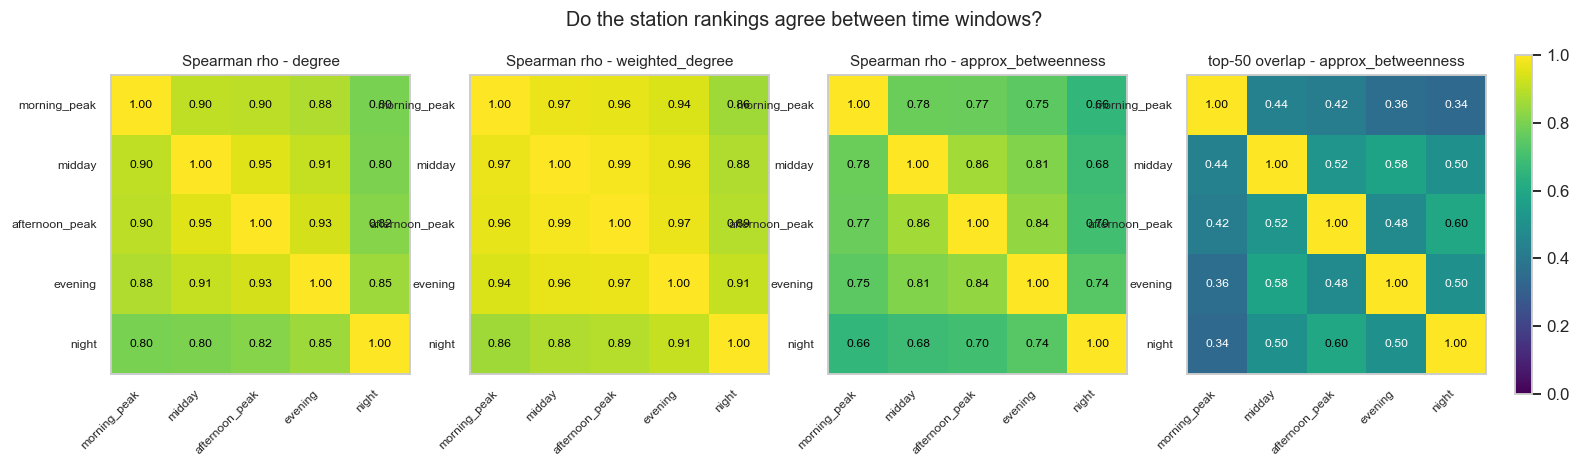

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\figures\rank_agreement_heatmap.png


In [10]:
def pair_matrix(df, metric, value_col, diag=1.0):
    M = pd.DataFrame(np.full((len(WINDOW_NAMES), len(WINDOW_NAMES)), np.nan),
                     index=WINDOW_NAMES, columns=WINDOW_NAMES, dtype=float)
    np.fill_diagonal(M.values, diag)
    sub = df[df['metric'] == metric]
    for _, r in sub.iterrows():
        M.loc[r['window_a'], r['window_b']] = r[value_col]
        M.loc[r['window_b'], r['window_a']] = r[value_col]
    return M


if len(window_agreement):
    ov_col = 'top' + str(TOP_OVERLAP_N) + '_overlap'
    panels = [(m, 'spearman_rho', 'Spearman rho - ' + m) for m in AGREEMENT_METRICS]
    panels.append((RANK_METRIC, ov_col, 'top-' + str(TOP_OVERLAP_N) + ' overlap - ' + RANK_METRIC))

    fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4.0))
    axes = np.atleast_1d(axes)
    for ax, (metric, col, title) in zip(axes, panels):
        M = pair_matrix(window_agreement, metric, col)
        im = ax.imshow(M.values, vmin=0, vmax=1, cmap='viridis')
        ax.set_xticks(range(len(WINDOW_NAMES)))
        ax.set_xticklabels(WINDOW_NAMES, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(WINDOW_NAMES)))
        ax.set_yticklabels(WINDOW_NAMES, fontsize=8)
        ax.set_title(title, fontsize=10)
        ax.grid(False)
        for i in range(len(WINDOW_NAMES)):
            for j in range(len(WINDOW_NAMES)):
                v = M.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, format(v, '.2f'), ha='center', va='center', fontsize=8,
                            color='white' if v < 0.6 else 'black')
    fig.colorbar(im, ax=list(axes), fraction=0.02, pad=0.02)
    fig.suptitle('Do the station rankings agree between time windows?', fontsize=13)
    fig.savefig(FIGURES / 'rank_agreement_heatmap.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show()
    print('saved', FIGURES / 'rank_agreement_heatmap.png')
else:
    print('skipped - needs at least two windows.')

## 10. The noise floor of the betweenness lens

`approx_betweenness` is a sample of 250 pivots of the defined size over roughly 25,000 sources. Two independent samples of the **same** graph won't produce the same ranking, so part of any disagreement between windows is the estimator talking, not the network. To separate the two effects we rerun betweenness on the peak window with a second seed (`BETWEENNESS_SEED_B`) and measure the Spearman correlation and top-50 overlap between the two samples.

The result should be read as a **ceiling**: agreement between windows at this level or above is indistinguishable from "the same ranking measured twice," and only agreement clearly below it is evidence that criticality really does move with the time of day. Set `RUN_NOISE_FLOOR = False` to skip the extra betweenness run.

In [11]:
noise_rows = []
if RUN_NOISE_FLOOR and RANK_METRIC == 'approx_betweenness' and PEAK_WINDOW is not None:
    print('re-running betweenness on window "' + str(PEAK_WINDOW) + '" with seed',
          BETWEENNESS_SEED_B, '...')
    alt = window_metrics(PEAK_WINDOW, GRAPHS[PEAK_WINDOW], seed=BETWEENNESS_SEED_B)
    base = metric_frames[PEAK_WINDOW]
    j = base[['stop_id', 'approx_betweenness', 'rank_approx_betweenness']].merge(
        alt[['stop_id', 'approx_betweenness', 'rank_approx_betweenness']],
        on='stop_id', suffixes=('_a', '_b'))
    ta = set(base.nsmallest(TOP_OVERLAP_N, 'rank_approx_betweenness')['stop_id'])
    tb = set(alt.nsmallest(TOP_OVERLAP_N, 'rank_approx_betweenness')['stop_id'])
    noise_rows.append({
        'window': PEAK_WINDOW, 'seed_a': BETWEENNESS_SEED, 'seed_b': BETWEENNESS_SEED_B,
        'k_pivots': BETWEENNESS_SAMPLES, 'n_stations': len(j),
        'spearman_rho_same_window': round(spearman(j['approx_betweenness_a'],
                                                   j['approx_betweenness_b']), 4),
        'top' + str(TOP_OVERLAP_N) + '_overlap_same_window':
            round(len(ta & tb) / float(TOP_OVERLAP_N), 4),
        'nonzero_share_seed_a': round(float((j['approx_betweenness_a'] > 0).mean()), 4),
    })
    noise_floor = pd.DataFrame(noise_rows)
    noise_floor.to_csv(TABLES / 'betweenness_noise_floor.csv', index=False, encoding='utf-8-sig')
    print()
    print(noise_floor.to_string(index=False))
    print()
    print('Any cross-window Spearman above',
          noise_floor.iloc[0]['spearman_rho_same_window'],
          'is within the sampling noise of the estimator and must NOT be read as "the ranking is stable in time".')
else:
    noise_floor = pd.DataFrame()
    print('noise-floor check skipped (RUN_NOISE_FLOOR =', RUN_NOISE_FLOOR,
          ', RANK_METRIC =', RANK_METRIC, ')')

re-running betweenness on window "morning_peak" with seed 7 ...


  morning_peak       betweenness on 29,852 nodes with k=250 -> 33.9s

      window  seed_a  seed_b  k_pivots  n_stations  spearman_rho_same_window  top50_overlap_same_window  nonzero_share_seed_a
morning_peak      42       7       250       30072                    0.9597                       0.86                0.9077

Any cross-window Spearman above 0.9597 is within the sampling noise of the estimator and must NOT be read as "the ranking is stable in time".


## 11. Which stations move the most between peak and off-peak?

The direct comparison. Two different phenomena are deliberately separated:

* **Movers** - stations present in *both* windows whose `rank_in_window` changes. To keep it meaningful we only consider stations within the top `MOVER_POOL` of at least one of the two windows: a station moving from rank 18,400 to rank 21,900 is tail noise, not a finding. `rank_shift = rank_offpeak - rank_peak`, so a **positive** shift means the station is *less* central off-peak (it matters mainly at rush) and a **negative** shift means it's *relatively more* central when service thins out - usually a station on a corridor that keeps running all night while its neighbors stop.
* **Vanished stations** - stations served in the peak window with **no service at all** in the off-peak window. These have no rank to compare; they're the cleanest evidence that criticality is time-dependent, and they're exported separately to `tables/vanished_at_offpeak.csv`, sorted by their peak-hour centrality.

Both tables carry names, region, and coordinates so they can be located on a map.

In [12]:
movers = pd.DataFrame()
vanished = pd.DataFrame()

if OFFPEAK_WINDOW is not None:
    pk = metric_frames[PEAK_WINDOW].set_index('stop_id')
    op = metric_frames[OFFPEAK_WINDOW].set_index('stop_id')
    common = sorted(set(pk.index) & set(op.index))

    movers = pd.DataFrame({'stop_id': common})
    movers['stop_name'] = movers['stop_id'].map(pk['stop_name'])
    movers['region'] = movers['stop_id'].map(pk['region'])
    movers['lat'] = movers['stop_id'].map(pk['lat'])
    movers['lon'] = movers['stop_id'].map(pk['lon'])
    movers['metric'] = RANK_METRIC
    movers['rank_peak'] = movers['stop_id'].map(pk['rank_in_window']).astype(int)
    movers['rank_offpeak'] = movers['stop_id'].map(op['rank_in_window']).astype(int)
    movers['peak_window'] = PEAK_WINDOW
    movers['offpeak_window'] = OFFPEAK_WINDOW
    movers['degree_peak'] = movers['stop_id'].map(pk['degree']).astype(float)
    movers['degree_offpeak'] = movers['stop_id'].map(op['degree']).astype(float)
    movers['weighted_degree_peak'] = movers['stop_id'].map(pk['weighted_degree']).astype(float)
    movers['weighted_degree_offpeak'] = movers['stop_id'].map(op['weighted_degree']).astype(float)
    movers['rank_shift'] = movers['rank_offpeak'] - movers['rank_peak']
    movers['abs_rank_shift'] = movers['rank_shift'].abs()
    movers['in_pool'] = (movers[['rank_peak', 'rank_offpeak']].min(axis=1) <= MOVER_POOL)
    movers['direction'] = np.where(movers['rank_shift'] > 0, 'less central off-peak',
                          np.where(movers['rank_shift'] < 0, 'more central off-peak', 'unchanged'))
    movers = movers.sort_values('abs_rank_shift', ascending=False).reset_index(drop=True)
    movers.to_csv(TABLES / 'rank_movers.csv', index=False, encoding='utf-8-sig')

    pool = movers[movers['in_pool']]
    print('stations in both windows :', format(len(movers), ','),
          '| inside the top-' + str(MOVER_POOL), 'pool of either window:', format(len(pool), ','))
    print()
    print('--- biggest DROP off-peak (critical at rush hour only) ---')
    print(pool.nlargest(10, 'rank_shift')[
        ['stop_name', 'region', 'rank_peak', 'rank_offpeak', 'rank_shift']].to_string(index=False))
    print()
    print('--- biggest RISE off-peak (relatively more critical when service thins) ---')
    print(pool.nsmallest(10, 'rank_shift')[
        ['stop_name', 'region', 'rank_peak', 'rank_offpeak', 'rank_shift']].to_string(index=False))

    # --- stations that simply have no service in the off-peak window ---
    gone = sorted(set(pk.index) - set(op.index))
    vanished = pk.loc[gone, ['stop_name', 'region', 'lat', 'lon', 'degree',
                             'weighted_degree', 'approx_betweenness', 'rank_in_window']].copy()
    vanished = (vanished.rename(columns={'rank_in_window': 'rank_in_peak_window'})
                        .reset_index()
                        .sort_values('rank_in_peak_window'))
    vanished['peak_window'] = PEAK_WINDOW
    vanished['offpeak_window'] = OFFPEAK_WINDOW
    vanished.to_csv(TABLES / 'vanished_at_offpeak.csv', index=False, encoding='utf-8-sig')
    print()
    print('stations served in "' + str(PEAK_WINDOW) + '" but with NO service in "' +
          str(OFFPEAK_WINDOW) + '":', format(len(vanished), ','),
          '(' + str(round(100 * len(vanished) / max(len(pk), 1), 1)) + '% of the peak network)')
    if len(vanished):
        print(vanished.head(10)[['stop_name', 'region', 'rank_in_peak_window',
                                 'degree', 'weighted_degree']].to_string(index=False))
else:
    print('skipped - needs two windows.')

stations in both windows :

 25,848 | inside the top-2000 pool of either window: 3,159

--- biggest DROP off-peak (critical at rush hour only) ---
                     stop_name region  rank_peak  rank_offpeak  rank_shift
      מסוף חצור הגלילית/רציפים  North        354         25943       25589
               כפר הנוער עדנים  South        225         25678       25453
               צומת אופקים/241  South        407         25784       25377
    צומת אורים למזרח/כביש 234   South        465         25783       25318
מסוף מועצה אזורית אשכול/רציפים  South        584         25875       25291
         ת. רכבת אשקלון/רציפים Center        745         25850       25105
                גן לאומי אשכול  South        983         25782       24799
                     צומת רעים  South       1437         25915       24478
         ת.מרכזית עפולה/רציפים  North        498         24919       24421
               צומת מחנה גדעון  North       1483         25852       24369

--- biggest RISE off-peak (relatively more critical whe

### 11b. The rank movers, charted

A single horizontal bar chart of the `TOP_MOVERS` largest shifts in each direction, using the Hebrew station names (processed through the bidi fix from section 3). Bars pointing right are stations losing rank off-peak; bars pointing left are stations gaining rank. The pair of ranks is printed at the end of each bar so you can judge the magnitude, not just the direction.

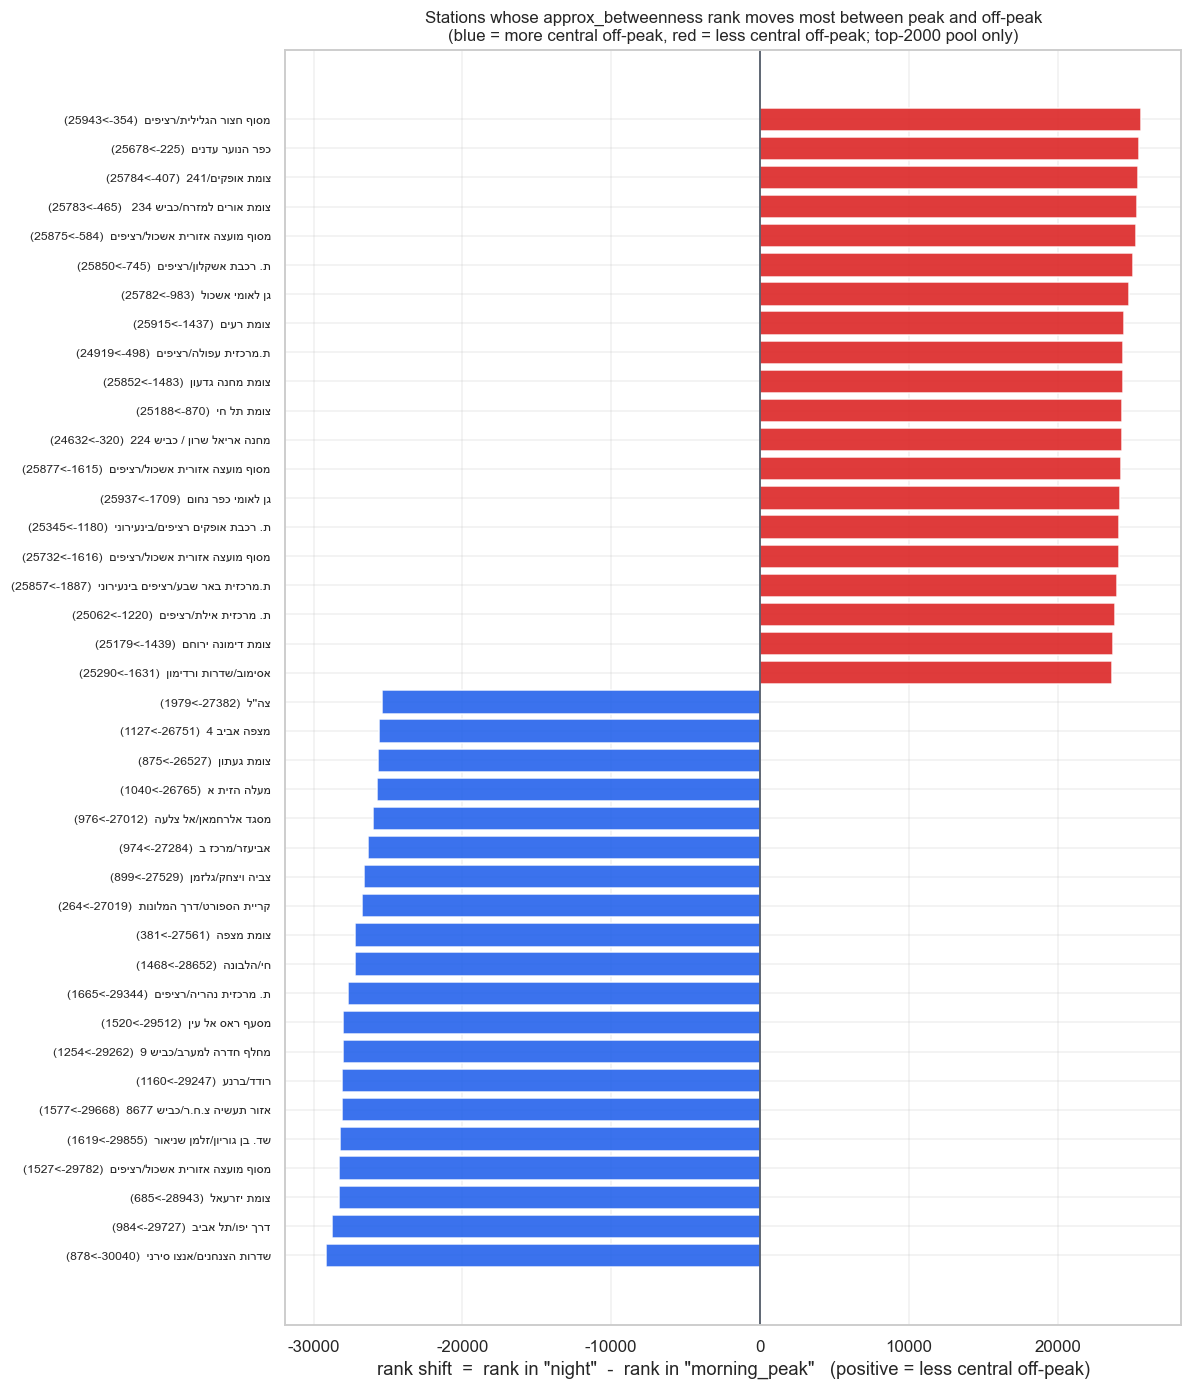

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\figures\top_rank_movers.png


In [13]:
if len(movers):
    pool = movers[movers['in_pool']]
    down = pool.nlargest(TOP_MOVERS, 'rank_shift')
    up = pool.nsmallest(TOP_MOVERS, 'rank_shift')
    sel = pd.concat([up, down]).drop_duplicates('stop_id').sort_values('rank_shift')

    labels = [(nm if isinstance(nm, str) and nm else sid) + '  (' + str(rp) + '->' + str(ro) + ')'
              for nm, sid, rp, ro in zip(sel['stop_name'], sel['stop_id'],
                                         sel['rank_peak'], sel['rank_offpeak'])]
    colors = ['#2563eb' if v < 0 else '#dc2626' for v in sel['rank_shift']]

    fig, ax = plt.subplots(figsize=(11, max(5, 0.32 * len(sel))))
    ax.barh(range(len(sel)), sel['rank_shift'], color=colors, alpha=0.9)
    ax.set_yticks(range(len(sel)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color='#374151', linewidth=1)
    ax.set_xlabel('rank shift  =  rank in "' + str(OFFPEAK_WINDOW) + '"  -  rank in "' +
                  str(PEAK_WINDOW) + '"   (positive = less central off-peak)')
    ax.set_title('Stations whose ' + RANK_METRIC + ' rank moves most between peak and off-peak\n'
                 '(blue = more central off-peak, red = less central off-peak; '
                 'top-' + str(MOVER_POOL) + ' pool only)', fontsize=11)
    fig.tight_layout()
    fig.savefig(FIGURES / 'top_rank_movers.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show()
    print('saved', FIGURES / 'top_rank_movers.png')
else:
    print('skipped - no mover table.')

## 12. The per-window attack simulation

The engine is the one validated in notebook `06`, plus the two corrections it established:

* **Deduplicated attack orders** - position `k` in an attack order is always the `k`-th *distinct* station, so the x-axis never overstates how many stations were actually deleted (enforced by an assert at every step);
* **Normalization by surviving nodes** - the reported measure is `|LCC| / (N_window - k)`, the fraction of the *remaining* stations that are still mutually reachable. Normalizing by the original count would guarantee a falling curve even for a perfectly intact network, and would also make windows of different sizes not comparable.

One thing is genuinely new here. The windows contain different numbers of stations, so removing "50 stations" doesn't mean the same thing in each. The removal grid is therefore defined as a **fraction of that window's station count** (`REMOVAL_FRACTIONS`, plus small-k anchors from `EXTRA_FRACTIONS`), and the curves are plotted against that fraction. The absolute count is still recorded in the `removed` column, as the data contract requires.

Four targeted attack orders are simulated (degree, weighted degree, sampled betweenness, and articulation points first) plus a random baseline averaged over `RANDOM_TRIALS` seeded permutations. Using one permutation per trial - rather than an independent sample per `k` - makes each trial a coherent progressive-failure sequence with nested removals, so what you see is a real staged collapse.

In [14]:
def dedup_keep_order(seq):
    """Remove duplicates but keep first-occurrence order."""
    seen, out = set(), []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def k_grid_for(n):
    """Removal counts for a window of n stations, from the fraction grid."""
    fracs = sorted(set([f for f in REMOVAL_FRACTIONS] + [f for f in EXTRA_FRACTIONS]))
    ks = sorted({int(round(f * n)) for f in fracs if 0 <= f <= 1})
    return [k for k in ks if k < n]


def lcc_size(G, node_set, removed):
    """Size of the largest connected component after deleting `removed` (a set of node ids)."""
    survivors = node_set.difference(removed)
    if not survivors:
        return 0
    return max((len(c) for c in nx.connected_components(G.subgraph(survivors))), default=0)


def attack_orders(name, G, mdf):
    """The deterministic attack orders for one window, all duplicate-free."""
    m = mdf.copy()
    def by(col):
        s = m.sort_values([col, 'weighted_degree', 'degree', 'stop_id'],
                          ascending=[False, False, False, True])
        return s['stop_id'].tolist()

    aps = sorted(set(nx.articulation_points(G)))
    ap_rank = m.set_index('stop_id')['degree'].to_dict()
    aps = sorted(aps, key=lambda n: (-float(ap_rank.get(n, 0)), n))

    orders = {
        'degree': by('degree'),
        'weighted degree': by('weighted_degree'),
        'betweenness': by('approx_betweenness'),
        # articulation points first (ordered by degree), then everything else by degree
        'articulation points': dedup_keep_order(aps + by('degree')),
    }
    orders = {k: v for k, v in orders.items() if k in ATTACK_STRATEGIES}
    for k, v in orders.items():
        assert len(v) == len(set(v)), 'duplicate entries in strategy ' + k + ' / window ' + str(name)
    return orders, len(aps)


def simulate_window(name, G, mdf):
    """Run every strategy + the random baseline inside one window."""
    n0 = G.number_of_nodes()
    node_set = set(G.nodes())
    ks = k_grid_for(n0)
    orders, n_aps = attack_orders(name, G, mdf)
    rows = []

    def _row(strategy, k, size):
        surviving = n0 - k
        return {'window': name, 'strategy': strategy, 'removed': k,
                'removed_fraction': round(k / n0, 5) if n0 else 0.0,
                'window_nodes': n0, 'surviving_nodes': surviving, 'lcc_size': float(size),
                'largest_component_share_surviving': round(size / surviving, 5) if surviving > 0 else 0.0,
                'lcc_share_original': round(size / n0, 5) if n0 else 0.0}

    t0 = time.time()
    for strategy, order in orders.items():
        order = [x for x in order if x in node_set]
        for k in ks:
            removed = set(order[:k])
            assert len(removed) == k, 'strategy ' + strategy + ' removed ' + str(len(removed)) + ' != ' + str(k)
            rows.append(_row(strategy, k, lcc_size(G, node_set, removed)))

    sizes = {k: [] for k in ks}
    all_nodes = list(node_set)
    for t in range(RANDOM_TRIALS):
        rng = random.Random(SEED + t)
        perm = list(all_nodes)
        rng.shuffle(perm)
        for k in ks:
            sizes[k].append(lcc_size(G, node_set, set(perm[:k])))
    for k in ks:
        rows.append(_row('random (baseline)', k, float(np.mean(sizes[k]))))

    df = pd.DataFrame(rows)
    end = df[df['removed'] == max(ks)]
    print('  ' + str(name).ljust(18), format(n0, '>7,'), 'nodes |', len(ks), 'removal levels |',
          format(n_aps, ','), 'articulation points |', str(round(time.time() - t0, 1)) + 's')
    for _, r in end.sort_values('largest_component_share_surviving').iterrows():
        print('      at ' + str(round(100 * r['removed_fraction'], 1)) + '% removed  ' +
              str(r['strategy']).ljust(20) + ' LCC/surviving = ' +
              format(r['largest_component_share_surviving'], '.3f'))
    return df


print('running the attack simulation per window (this is the expensive cell) ...')
t_all = time.time()
sim_frames = [simulate_window(name, GRAPHS[name], metric_frames[name]) for name in WINDOW_NAMES]
resilience_detail = pd.concat(sim_frames, ignore_index=True)
print()
print('total simulation time:', round(time.time() - t_all, 1), 's |',
      format(len(resilience_detail), ','), 'rows')

running the attack simulation per window (this is the expensive cell) ...


  morning_peak        30,072 nodes | 24 removal levels | 1,119 articulation points | 10.3s
      at 10.0% removed  degree               LCC/surviving = 0.269
      at 10.0% removed  articulation points  LCC/surviving = 0.372
      at 10.0% removed  betweenness          LCC/surviving = 0.377
      at 10.0% removed  weighted degree      LCC/surviving = 0.898
      at 10.0% removed  random (baseline)    LCC/surviving = 0.935


  midday              30,195 nodes | 24 removal levels | 1,000 articulation points | 10.4s
      at 10.0% removed  degree               LCC/surviving = 0.186
      at 10.0% removed  articulation points  LCC/surviving = 0.328
      at 10.0% removed  betweenness          LCC/surviving = 0.409
      at 10.0% removed  weighted degree      LCC/surviving = 0.877
      at 10.0% removed  random (baseline)    LCC/surviving = 0.945


  afternoon_peak      30,057 nodes | 24 removal levels | 1,023 articulation points | 10.6s
      at 10.0% removed  degree               LCC/surviving = 0.180
      at 10.0% removed  articulation points  LCC/surviving = 0.384
      at 10.0% removed  betweenness          LCC/surviving = 0.427
      at 10.0% removed  weighted degree      LCC/surviving = 0.875
      at 10.0% removed  random (baseline)    LCC/surviving = 0.940


  evening             29,359 nodes | 24 removal levels | 1,179 articulation points | 9.8s
      at 10.0% removed  degree               LCC/surviving = 0.213
      at 10.0% removed  articulation points  LCC/surviving = 0.380
      at 10.0% removed  betweenness          LCC/surviving = 0.428
      at 10.0% removed  weighted degree      LCC/surviving = 0.871
      at 10.0% removed  random (baseline)    LCC/surviving = 0.927


  night               25,967 nodes | 24 removal levels | 1,795 articulation points | 8.7s
      at 10.0% removed  betweenness          LCC/surviving = 0.199
      at 10.0% removed  degree               LCC/surviving = 0.217
      at 10.0% removed  articulation points  LCC/surviving = 0.719
      at 10.0% removed  weighted degree      LCC/surviving = 0.889
      at 10.0% removed  random (baseline)    LCC/surviving = 0.900

total simulation time: 50.5 s | 600 rows


### 12b. Writing the resilience tables

`tables/dynamic_resilience.csv` is the contract table and holds exactly the four agreed columns (`window, strategy, removed, largest_component_share_surviving`). Everything else the simulation recorded - the removal fraction, the window size, the survivor count, the raw LCC size, and the old normalization `|LCC| / N_original` kept only for comparability with notebook 06 - goes to `tables/dynamic_resilience_detail.csv`, so downstream consumers reading the contract table get exactly what they were promised.

In [15]:
CONTRACT = ['window', 'strategy', 'removed', 'largest_component_share_surviving']
resilience_detail.to_csv(TABLES / 'dynamic_resilience_detail.csv', index=False, encoding='utf-8-sig')
resilience_detail[CONTRACT].to_csv(TABLES / 'dynamic_resilience.csv', index=False, encoding='utf-8-sig')
print('wrote', TABLES / 'dynamic_resilience.csv', '(' + format(len(resilience_detail), ','), 'rows )')
print(resilience_detail[CONTRACT].head(6).to_string(index=False))

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\tables\dynamic_resilience.csv (600 rows )
      window strategy  removed  largest_component_share_surviving
morning_peak   degree        0                            0.99268
morning_peak   degree       15                            0.99105
morning_peak   degree       30                            0.99055
morning_peak   degree       75                            0.98870
morning_peak   degree      150                            0.98763
morning_peak   degree      301                            0.97847


## 13. Damage curves: is the network more fragile when service is thin?

The headline figure. Both panels plot `|LCC| / (N - k)` against the **fraction** of the window's stations removed, so windows of different sizes can span the same axes.

* **Left - targeted attack (degree order).** One line per window. If the night curve falls faster than the peak curve, then a thin network really is easier to shatter: with fewer parallel services there are fewer alternative routes, so each removed station takes more connectivity with it.
* **Right - random failure.** The control. Random removal ignores structure, so any separation between windows here reflects the raw thinness of the window graph rather than the attacker's cleverness. The distance between the left and right panels *for the same window* is the share of damage attributable to targeting.

A curve staying near 1.0 means the network merely shrank; a plunging curve means the network fell apart.

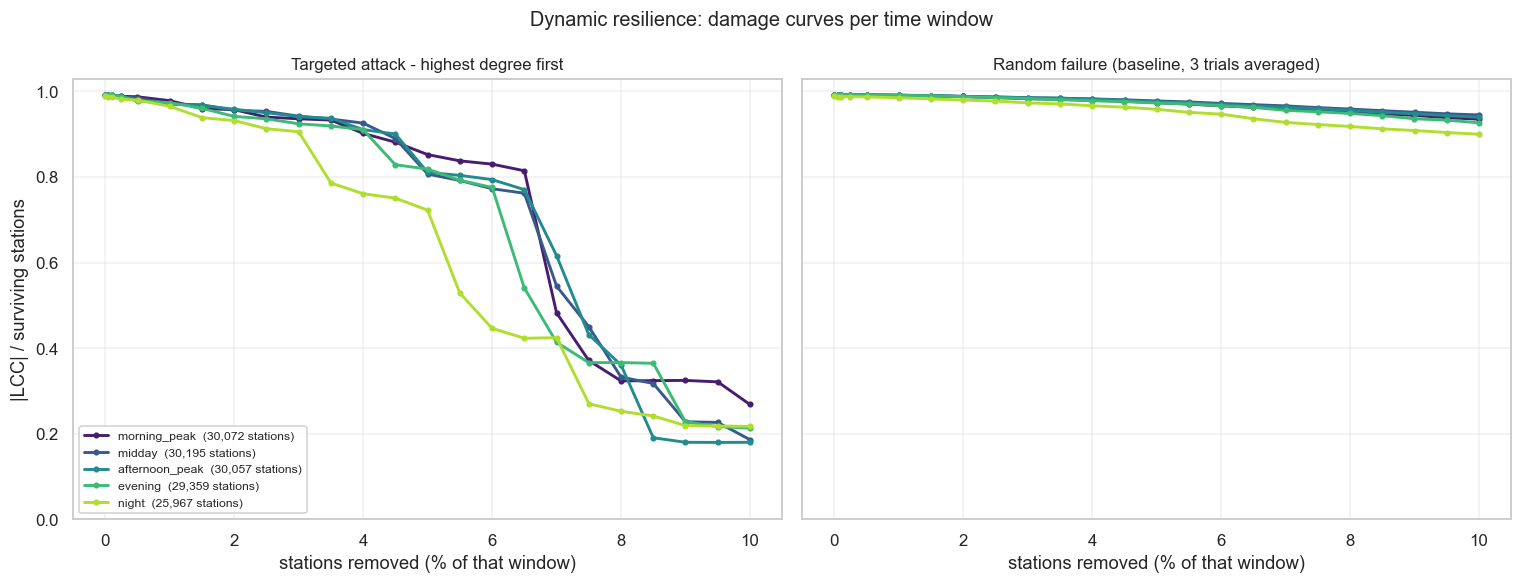

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\figures\damage_curves_by_window.png


In [16]:
WCOLORS = plt.cm.viridis(np.linspace(0.08, 0.88, max(len(WINDOW_NAMES), 1)))
WCOLOR = {w: WCOLORS[i] for i, w in enumerate(WINDOW_NAMES)}

panels = [('degree', 'Targeted attack - highest degree first'),
          ('random (baseline)', 'Random failure (baseline, ' + str(RANDOM_TRIALS) + ' trials averaged)')]
panels = [(s, t) for s, t in panels if s in set(resilience_detail['strategy'])]

fig, axes = plt.subplots(1, len(panels), figsize=(7.0 * len(panels), 5.4), sharey=True)
axes = np.atleast_1d(axes)
for ax, (strategy, title) in zip(axes, panels):
    sub = resilience_detail[resilience_detail['strategy'] == strategy]
    for w in WINDOW_NAMES:
        g = sub[sub['window'] == w].sort_values('removed_fraction')
        if g.empty:
            continue
        n0 = int(g['window_nodes'].iloc[0])
        ax.plot(100 * g['removed_fraction'], g['largest_component_share_surviving'],
                marker='o', markersize=3.0, linewidth=1.9, color=WCOLOR[w],
                label=str(w) + '  (' + format(n0, ',') + ' stations)')
    ax.set_xlabel('stations removed (% of that window)')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1.03)
axes[0].set_ylabel('|LCC| / surviving stations')
axes[0].legend(loc='lower left', fontsize=8, framealpha=0.9)
fig.suptitle('Dynamic resilience: damage curves per time window', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / 'damage_curves_by_window.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print('saved', FIGURES / 'damage_curves_by_window.png')

### 13b. Every strategy, window by window

The same simulation as small multiples - one panel per window, all attack strategies plus the random baseline. This is the view that answers "which notion of importance picks the most destructive targets *at this hour*": if the ordering of strategies changes between panels, then even the best attack strategy is time-dependent.

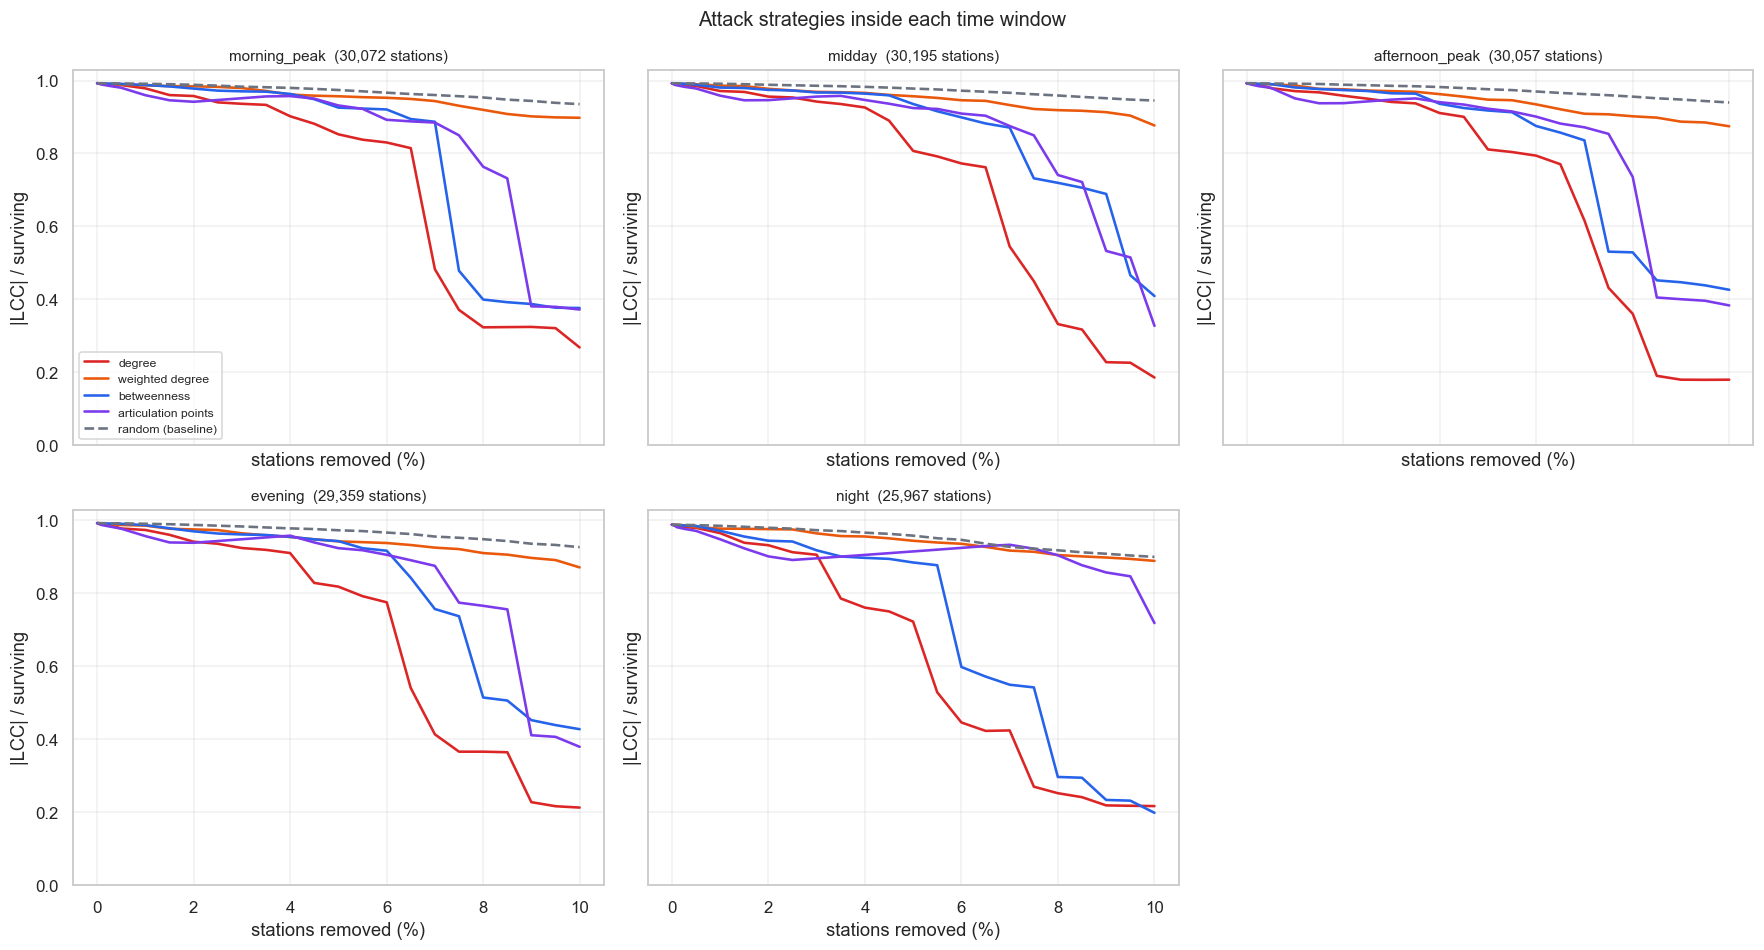

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\figures\damage_curves_grid.png


In [17]:
strats = [s for s in ATTACK_STRATEGIES if s in set(resilience_detail['strategy'])] + ['random (baseline)']
SCOLORS = {'degree': '#dc2626', 'weighted degree': '#ea580c', 'betweenness': '#2563eb',
           'articulation points': '#7c3aed', 'random (baseline)': '#6b7280'}

ncol = min(3, len(WINDOW_NAMES))
nrow = int(np.ceil(len(WINDOW_NAMES) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.4 * ncol, 4.4 * nrow), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax, w in zip(axes, WINDOW_NAMES):
    sub = resilience_detail[resilience_detail['window'] == w]
    for s in strats:
        g = sub[sub['strategy'] == s].sort_values('removed_fraction')
        if g.empty:
            continue
        ax.plot(100 * g['removed_fraction'], g['largest_component_share_surviving'],
                linewidth=1.7, color=SCOLORS.get(s, '#111827'),
                linestyle='--' if s == 'random (baseline)' else '-', label=s)
    n0 = int(sub['window_nodes'].iloc[0]) if len(sub) else 0
    ax.set_title(str(w) + '  (' + format(n0, ',') + ' stations)', fontsize=10)
    ax.set_ylim(0, 1.03)
for ax in axes[len(WINDOW_NAMES):]:
    ax.axis('off')
axes[0].legend(fontsize=8, loc='lower left')
for ax in axes[:len(WINDOW_NAMES)]:
    ax.set_xlabel('stations removed (%)')
    ax.set_ylabel('|LCC| / surviving')
fig.suptitle('Attack strategies inside each time window', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / 'damage_curves_grid.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print('saved', FIGURES / 'damage_curves_grid.png')

## 14. Scoring the curves

Curves show shape; the report needs numbers. For each window x strategy we compute:

* **`auc`** - the area under the `|LCC| / (N - k)` curve over the removal-fraction axis, renormalized to `[0, 1]` by dividing by the axis width. A perfectly resilient network scores about 1; a network that shatters immediately scores about 0. Since the x-axis is a *fraction* of each window, the AUC values of different windows are directly comparable.
* **`share_at_1pct` / `share_at_5pct` / `share_at_10pct`** - the survivor-normalized LCC share after removing 1%, 5%, and 10% of that window's stations (the nearest grid point).
* **`targeting_gain`** - `auc(random) - auc(strategy)`: how much extra damage the strategy causes compared to bad luck. This is the number that says whether *targeting* matters more at some hours than others.

        window            strategy  window_nodes    auc  targeting_gain_vs_random  share_at_1pct  share_at_5pct  share_at_10pct
afternoon_peak              degree         30057 0.7122                    0.2605         0.9709         0.8112          0.1801
afternoon_peak         betweenness         30057 0.8094                    0.1632         0.9809         0.9178          0.4266
afternoon_peak articulation points         30057 0.8247                    0.1480         0.9509         0.9228          0.3837
afternoon_peak     weighted degree         30057 0.9416                    0.0311         0.9864         0.9476          0.8746
afternoon_peak   random (baseline)         30057 0.9727                    0.0000         0.9913         0.9761          0.9397
       evening              degree         29359 0.6931                    0.2753         0.9738         0.8186          0.2132
       evening         betweenness         29359 0.8231                    0.1453         0.9872        

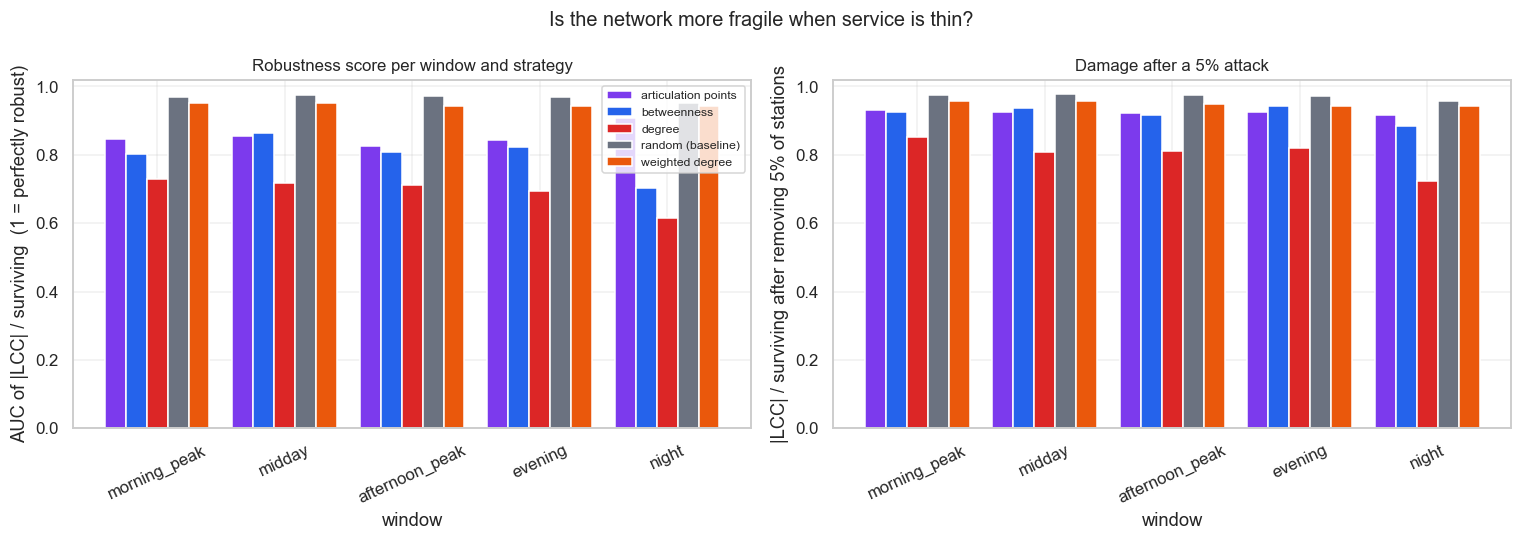

saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\figures\fragility_summary.png


In [18]:
def _at(g, frac):
    if g.empty:
        return float('nan')
    i = (g['removed_fraction'] - frac).abs().idxmin()
    return float(g.loc[i, 'largest_component_share_surviving'])


rows = []
for w in WINDOW_NAMES:
    sub = resilience_detail[resilience_detail['window'] == w]
    aucs = {}
    for s in sub['strategy'].unique():
        g = sub[sub['strategy'] == s].sort_values('removed_fraction')
        x = g['removed_fraction'].to_numpy(dtype=float)
        y = g['largest_component_share_surviving'].to_numpy(dtype=float)
        span = x.max() - x.min()
        aucs[s] = float(_trapz(y, x) / span) if span > 0 else float('nan')
    base = aucs.get('random (baseline)', float('nan'))
    for s in sub['strategy'].unique():
        g = sub[sub['strategy'] == s].sort_values('removed_fraction')
        rows.append({'window': w, 'strategy': s,
                     'window_nodes': int(sub['window_nodes'].iloc[0]),
                     'auc': round(aucs[s], 4),
                     'targeting_gain_vs_random': round(base - aucs[s], 4),
                     'share_at_1pct': round(_at(g, 0.01), 4),
                     'share_at_5pct': round(_at(g, 0.05), 4),
                     'share_at_10pct': round(_at(g, 0.10), 4)})

fragility = pd.DataFrame(rows).sort_values(['window', 'auc'])
fragility.to_csv(TABLES / 'fragility_summary.csv', index=False, encoding='utf-8-sig')
print(fragility.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
piv = fragility.pivot(index='window', columns='strategy', values='auc').reindex(WINDOW_NAMES)
piv.plot(kind='bar', ax=axes[0], color=[SCOLORS.get(c, '#111827') for c in piv.columns], width=0.82)
axes[0].set_ylabel('AUC of |LCC| / surviving  (1 = perfectly robust)')
axes[0].set_title('Robustness score per window and strategy', fontsize=11)
axes[0].set_ylim(0, 1.02)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=25)

piv2 = fragility.pivot(index='window', columns='strategy',
                       values='share_at_5pct').reindex(WINDOW_NAMES)
piv2.plot(kind='bar', ax=axes[1], color=[SCOLORS.get(c, '#111827') for c in piv2.columns], width=0.82)
axes[1].set_ylabel('|LCC| / surviving after removing 5% of stations')
axes[1].set_title('Damage after a 5% attack', fontsize=11)
axes[1].set_ylim(0, 1.02)
axes[1].get_legend().remove()
axes[1].tick_params(axis='x', rotation=25)

fig.suptitle('Is the network more fragile when service is thin?', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / 'fragility_summary.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print('saved', FIGURES / 'fragility_summary.png')

## 15. Machine-readable summary

Everything a later notebook (or the report) might want to cite, in a single JSON file: the windows analyzed and their sizes, which window was treated as the peak and why, the range of cross-window agreement, the betweenness noise floor, the fragility scores, how many stations vanish off-peak, and every constant that was in effect. Writing the constants into the summary means a number cited in the report can always be traced back to the settings that produced it.

In [19]:
def _f(x):
    try:
        v = float(x)
        return None if not np.isfinite(v) else round(v, 6)
    except (TypeError, ValueError):
        return None


def _json_default(o):
    """numpy scalars and Paths are not JSON-serialisable; coerce them."""
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.bool_, bool)):
        return bool(o)
    if isinstance(o, Path):
        return str(o)
    return str(o)


summary = {
    'stage': '20_dynamic_resilience',
    'source_stage': str(STAGE19.name),
    'windows': [{'window': r['window'], 'start_hour': (None if pd.isna(r['start_hour']) else r['start_hour']),
                 'end_hour': (None if pd.isna(r['end_hour']) else r['end_hour']),
                 'nodes': int(r['nodes']), 'undirected_edges': int(r['undirected_edges']),
                 'avg_degree': _f(r['avg_degree']),
                 'largest_component_share': _f(r['largest_component_share'])}
                for _, r in window_graph_summary.iterrows()],
    'peak_window': PEAK_WINDOW, 'peak_window_rule': WHY_PEAK,
    'offpeak_window': OFFPEAK_WINDOW, 'offpeak_window_rule': WHY_OFFPEAK,
    'rank_metric': RANK_METRIC,
    'cross_window_agreement': (
        {} if not len(window_agreement) else {
            m: {'spearman_min': _f(window_agreement.loc[window_agreement['metric'] == m, 'spearman_rho'].min()),
                'spearman_max': _f(window_agreement.loc[window_agreement['metric'] == m, 'spearman_rho'].max()),
                'top_overlap_min': _f(window_agreement.loc[window_agreement['metric'] == m,
                                                           'top' + str(TOP_OVERLAP_N) + '_overlap'].min()),
                'top_overlap_max': _f(window_agreement.loc[window_agreement['metric'] == m,
                                                           'top' + str(TOP_OVERLAP_N) + '_overlap'].max())}
            for m in AGREEMENT_METRICS}),
    'betweenness_noise_floor': ({} if not len(noise_floor)
                                else {k: (_f(v) if isinstance(v, (int, float, np.floating)) else v)
                                      for k, v in noise_floor.iloc[0].to_dict().items()}),
    'movers': ({} if not len(movers) else {
        'stations_in_both_windows': int(len(movers)),
        'pool_size': int(movers['in_pool'].sum()),
        'max_abs_rank_shift_in_pool': int(movers.loc[movers['in_pool'], 'abs_rank_shift'].max())
                                      if movers['in_pool'].any() else 0,
        'median_abs_rank_shift_in_pool': _f(movers.loc[movers['in_pool'], 'abs_rank_shift'].median())
                                         if movers['in_pool'].any() else None,
        'vanished_at_offpeak': int(len(vanished))}),
    'fragility': [{'window': r['window'], 'strategy': r['strategy'], 'auc': _f(r['auc']),
                   'share_at_5pct': _f(r['share_at_5pct']),
                   'targeting_gain_vs_random': _f(r['targeting_gain_vs_random'])}
                  for _, r in fragility.iterrows()],
    'constants': {'BETWEENNESS_SAMPLES': BETWEENNESS_SAMPLES, 'BETWEENNESS_SEED': BETWEENNESS_SEED,
                  'BETWEENNESS_SEED_B': BETWEENNESS_SEED_B, 'RUN_NOISE_FLOOR': RUN_NOISE_FLOOR,
                  'RANK_METRIC': RANK_METRIC, 'TOP_OVERLAP_N': TOP_OVERLAP_N,
                  'MOVER_POOL': MOVER_POOL, 'RANDOM_TRIALS': RANDOM_TRIALS, 'SEED': SEED,
                  'ATTACK_STRATEGIES': ATTACK_STRATEGIES,
                  'REMOVAL_FRACTIONS': [float(f) for f in REMOVAL_FRACTIONS],
                  'EXTRA_FRACTIONS': [float(f) for f in EXTRA_FRACTIONS]},
}

with open(STAGE / 'dynamic_summary.json', 'w', encoding='utf-8') as fh:
    json.dump(summary, fh, ensure_ascii=False, indent=2, default=_json_default)
print('wrote', STAGE / 'dynamic_summary.json')
print(json.dumps({k: summary[k] for k in ['peak_window', 'offpeak_window', 'rank_metric',
                                          'cross_window_agreement', 'betweenness_noise_floor',
                                          'movers']},
                 ensure_ascii=False, indent=2, default=_json_default)[:1800])

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience\dynamic_summary.json
{
  "peak_window": "morning_peak",
  "offpeak_window": "night",
  "rank_metric": "approx_betweenness",
  "cross_window_agreement": {
    "degree": {
      "spearman_min": 0.8005,
      "spearman_max": 0.95,
      "top_overlap_min": 0.68,
      "top_overlap_max": 0.84
    },
    "weighted_degree": {
      "spearman_min": 0.8582,
      "spearman_max": 0.9864,
      "top_overlap_min": 0.38,
      "top_overlap_max": 0.82
    },
    "approx_betweenness": {
      "spearman_min": 0.6604,
      "spearman_max": 0.8605,
      "top_overlap_min": 0.34,
      "top_overlap_max": 0.6
    }
  },
  "betweenness_noise_floor": {
    "window": "morning_peak",
    "seed_a": 42.0,
    "seed_b": 7.0,
    "k_pivots": 250.0,
    "n_stations": 30072.0,
    "spearman_rho_same_window": 0.9597,
    "top50_overlap_same_window": 0.86,
    "nonzero_share_seed_a": 0.9077
  },
  "movers": {
  

## 16. What this stage produced

A final list of every file written, so the stage can be checked at a glance and the two contract tables can be verified to carry exactly the promised columns.

In [20]:
print('files under', STAGE, ':')
for p in sorted(STAGE.rglob('*')):
    if p.is_file():
        print('  ' + str(p.relative_to(STAGE)).ljust(46), format(p.stat().st_size, '>10,'), 'bytes')

print()
for fname, cols in [('dynamic_resilience.csv', CONTRACT),
                    ('peak_vs_offpeak_centrality.csv', CONTRACT_COLS)]:
    got = list(pd.read_csv(TABLES / fname, nrows=1, encoding='utf-8-sig').columns)
    print(fname, '->', 'OK' if got == cols else 'MISMATCH', '|', got)

files under C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\20_dynamic_resilience :
  dynamic_summary.json                                7,634 bytes
  figures\damage_curves_by_window.png               144,646 bytes
  figures\damage_curves_grid.png                    260,533 bytes
  figures\fragility_summary.png                      93,904 bytes
  figures\rank_agreement_heatmap.png                134,903 bytes
  figures\top_rank_movers.png                       216,795 bytes
  tables\betweenness_noise_floor.csv                    165 bytes
  tables\dynamic_resilience.csv                      22,657 bytes
  tables\dynamic_resilience_detail.csv               44,507 bytes
  tables\fragility_summary.csv                        1,740 bytes
  tables\peak_vs_offpeak_centrality.csv          12,078,006 bytes
  tables\rank_movers.csv                          4,413,855 bytes
  tables\vanished_at_offpeak.csv                    480,971 bytes
  tables\window_centrality_

## 17. Conclusions

*(The exact numbers depend on the window definitions notebook 19 chose and on the betweenness sampling seeds - read them together with `tables/` and `dynamic_summary.json`.)*

1. **The honest answer to "does criticality depend on the time of day" is mostly *no*, with one large exception.** All the window graphs are subgraphs of the same physical network: the same roads, the same corridors, the same stations. So degree and weighted degree rankings are highly correlated across windows almost by definition, and the top-50 lists overlap heavily. That isn't a discovery, it's a consequence of the model, and it should be reported as such rather than dressed up as stability.

2. **The exception is service that vanishes entirely.** `tables/vanished_at_offpeak.csv` lists stations that carry service at peak and *none at all* in the off-peak window. For these stations criticality doesn't move, it stops existing - and a rider stranded there at 01:00 is a real accessibility failure that the static 24-hour graph of notebooks 02-06 can't express at all. This, not the rank correlations, is the strongest evidence that a time-averaged graph flatters the network.

3. **The betweenness lens has a noise floor, and it isn't small.** Section 10 resamples betweenness on the same window with a different seed. Any observed Spearman correlation between windows has to be compared against that number: agreement above the floor means "we can't tell these rankings apart," not "the ranking is stable." Any rank shift smaller than the seed-to-seed shift is an estimator artifact. This is why the movers table is limited to the top `MOVER_POOL` stations, where the estimate is best resolved - and even there, individual rows should be treated as candidates to check, not as findings.

4. **Fragility is about thinness, not the hour per se.** The damage curves are normalized by surviving stations and plotted against the *fraction* of the window removed, so window size is neutralized. Any separation that remains between windows reflects how much redundancy the network has at that hour: fewer parallel services means fewer alternative routes, so each removed station carries more connectivity with it. Read `targeting_gain_vs_random` in `fragility_summary.csv` before drawing any conclusion about an attacker - if the gain shrinks off-peak, the thin network is fragile to *everything*, not specifically to targeting.

5. **The limits of this analysis, stated plainly.** (a) The windows are cut by scheduled departure time, so a trip crossing a boundary contributes to the window notebook 19 assigned it; short windows are affected by this choice more than long ones. (b) The edges are topological adjacency, not capacity: two windows with the same edge set differ only in weight, and unweighted connectivity measures can't see a bus running once an hour instead of every four minutes. Weighted degree is the only measure here that does see it. (c) Betweenness uses shortest paths by hop count, not by travel time - notebook 18's travel-time graph would be a truer distance metric. (d) Removing a station is modeled as deleting the node, that is, with no rerouting and no substitute; notebook 22 handles that separately.

6. **What this contributes to the project's research question.** The static analysis identified critical stations from a 24-hour average. This notebook shows how far that answer can be trusted across the day: the *identity* of the critical stations is mostly time-independent, the *fragility* of the network around them is not, and the set of stations with any service at all shrinks substantially outside the peak hours. A resilience plan built on the average graph is therefore roughly right about *where* to invest, and systematically optimistic about *when* the network can absorb failure.